# Janome による日本語の形態素解析

## 青空文庫のテキストファイルの読み込み

In [8]:
src = "jigokuhen_shinji.txt"            # 同じフォルダにあるテキストファイルの名前
f = open(src, encoding="shift_jis")
text = src_text = f.read()
f.close()

import re
title = re.split(r'\n', text)[0]        # タイトル
auther = re.split(r'\n', text)[1]       # 著者

text = re.split(r'\-{5,}', text)[2]     # ヘッダの除去
text = re.split(r'底本：', text)[0]     # フッタの除去
text = re.sub(r'《.+?》', '', text)     # ルビの除去
text = re.sub(r'［＃.+?］', '', text)   # 入力者注の削除 → 外字は削除される
text = text.strip()
print(text)

一

　堀川の大殿様のやうな方は、これまでは固より、後の世には恐らく二人とはいらつしやいますまい。噂に聞きますと、あの方の御誕生になる前には、大威徳明王の御姿が御母君の夢枕にお立ちになつたとか申す事でございますが、兎に角御生れつきから、並々の人間とは御違ひになつてゐたやうでございます。でございますから、あの方の為さいました事には、一つとして私どもの意表に出てゐないものはございません。早い話が堀川のお邸の御規模を拝見致しましても、壮大と申しませうか、豪放と申しませうか、到底私どもの凡慮には及ばない、思ひ切つた所があるやうでございます。中にはまた、そこを色々とあげつらつて大殿様の御性行を始皇帝や煬帝に比べるものもございますが、それは諺に云ふ群盲の象を撫でるやうなものでもございませうか。あの方の御思召は、決してそのやうに御自分ばかり、栄耀栄華をなさらうと申すのではございません。それよりはもつと下々の事まで御考へになる、云はば天下と共に楽しむとでも申しさうな、大腹中の御器量がございました。
　それでございますから、二条大宮の百鬼夜行に御遇ひになつても、格別｜御障りがなかつたのでございませう。又｜陸奥の塩竈の景色を写したので名高いあの東三条の河原院に、夜な／＼現はれると云ふ噂のあつた融の左大臣の霊でさへ、大殿様のお叱りを受けては、姿を消したのに相違ございますまい。かやうな御威光でございますから、その頃洛中の老若男女が、大殿様と申しますと、まるで権者の再来のやうに尊み合ひましたも、決して無理ではございません。何時ぞや、内の梅花の宴からの御帰りに御車の牛が放れて、折から通りかゝつた老人に怪我をさせました時でさへ、その老人は手を合せて、大殿様の牛にかけられた事を難有がつたと申す事でございます。
　さやうな次第でございますから、大殿様御一代の間には、後々までも語り草になりますやうな事が、随分沢山にございました。大饗の引出物に白馬ばかりを三十頭、賜つたこともございますし、長良の橋の橋柱に御寵愛の童を立てた事もございますし、それから又｜華陀の術を伝へた震旦の僧に、御腿の瘡を御切らせになつた事もございますし、――一々数へ立てゝ居りましては、とても際限がございません。が、その数多い御逸事の中でも、今では御家の重宝になつて居ります地獄変の屏風の由来程、恐ろしい話はございますまい。日頃は物に御騒

## 形態素解析

In [9]:
# ライブラリから，必要な関数をインポート
from janome.tokenizer import Tokenizer
from janome.analyzer import Analyzer
from janome.tokenfilter import *

# 記号を取り除き，複合名詞は1つの名詞にまとめて，形態素解析を行う
tokenizer = Tokenizer()
token_filters = [CompoundNounFilter(), POSStopFilter('記号')]
a = Analyzer(tokenizer=tokenizer, token_filters=token_filters)

# 結果を表の形にして表示する
tab = [[t.surface] + t.part_of_speech.split(',') +
       [t.infl_type, t.infl_form, t.base_form, t.reading, t.phonetic]
       for t in a.analyze(text)]

import pandas as pd
tokens = pd.DataFrame(tab)
tokens.columns = [
    '表層形', '品詞', '品詞細分類1', '品詞細分類2', '品詞細分類3',
    '活用型', '活用形', '原形', '読み', '発音'
    ]
#tokens.to_csv('tokens.csv', index=False, encoding='utf_8_sig')

display(tokens)

,表層形,品詞,品詞細分類1,品詞細分類2,品詞細分類3,活用型,活用形,原形,読み,発音
0,一,名詞,数,*,*,*,*,一,イチ,イチ
1,堀川,名詞,固有名詞,人名,姓,*,*,堀川,ホリカワ,ホリカワ
2,の,助詞,連体化,*,*,*,*,の,ノ,ノ
3,大,接頭詞,名詞接続,*,*,*,*,大,ダイ,ダイ
4,殿様,名詞,一般,*,*,*,*,殿様,トノサマ,トノサマ
...,...,...,...,...,...,...,...,...,...,...
15353,ひ,動詞,自立,*,*,一段,連用形,ひる,ヒ,ヒ
15354,ござい,助動詞,*,*,*,五段・ラ行特殊,連用形,ござる,ゴザイ,ゴザイ
15355,ませ,助動詞,*,*,*,特殊・マス,未然形,ます,マセ,マセ
15356,ん,助動詞,*,*,*,不変化型,基本形,ん,ン,ン


# 日本語ワードクラウドの生成

In [10]:
# 名詞, 動詞, 形容詞に限定して単語の(原形の)リストを作る
ind_filters = [CompoundNounFilter(), POSKeepFilter(['名詞', '動詞', '形容詞'])]
a2 = Analyzer(tokenizer=tokenizer, token_filters=ind_filters)
words_list = [ t.base_form for t in a2.analyze(text)]

print(words_list)

['一', '堀川', '殿様', 'やう', '方', 'これ', '固い', '後', '世', '二人', 'いる', 'やく', '噂', '聞く', '方', '誕生', 'なる', '前', '威徳明王', '姿', '母君', '夢枕', 'お立ち', 'なつ', '申す', '事', '兎', '角', '生れつき', '並々', '人間', '違', 'ひる', 'つて', 'ゐる', 'やう', '方', '為す', 'いる', '事', '一つ', '私ども', '意表', '出る', 'ゐる', 'もの', '早い', '話', '堀川', '邸', '規模', '拝見', '致す', '壮大', '申す', '豪放', '申す', '私ども', '凡慮', '及ぶ', '思ふ', '切る', 'つた所', 'ある', 'やう', '中', 'そこ', 'あげつらる', 'つて大殿様', '性行', '始皇帝', '煬帝', '比べる', 'もの', 'それ', '諺', '云', 'ふる', '群盲', '象', '撫でる', 'やう', 'もの', '方', '思召', 'やう', '自分', '栄耀栄華', 'なさる', '申す', 'の', 'それ', 'もつ', '下々', '事', '考', 'なる', '云', '天下', '楽しむ', '申す', 'さ', '腹中', '器量', 'ござる', 'それ', '二条大宮', '百鬼夜行', '遇', 'ひる', 'つて', '格別', '障り', 'の', '陸奥', '塩竈', '景色', '写す', '名高い', '東三条', '河原院', '夜', 'はれる', '云', 'ふる', '噂', 'あつい', '融', '左大臣', '霊', 'さ', '殿様', '叱る', '受ける', '姿', '消す', '相違', 'ござる', 'やう', '威光', '頃洛中', '老若男女', '殿様', '申す', '権者', '再来', 'やう', '尊い', 'みる', '合', 'ひる', '無理', '内', '梅花', '宴', '帰り', '車', '牛', '放れる', '折', '通り', 'つた老人', '怪我', 'する', 'せる', '時', 'さ', 

In [13]:
# 一部の頻出語を除去する
rm_words = [
    "ある", "いる", "する", "せる", "なる", "これ", "それ", "あれ", "どれ",
    "この", "その", "あの", "どの", "もの", "こと", "よう", "れる", "られる",
    "の","ない","やう","ゐる","居る"
    ]
for rw in rm_words:
    words_list = [w for w in words_list if w!=rw]

# 単語のリストを一つのテキスト(文字列)にまとめる
words = ' '.join(words_list)

display(words)

'一 堀川 殿様 方 固い 後 世 二人 やく 噂 聞く 方 誕生 前 威徳明王 姿 母君 夢枕 お立ち なつ 申す 事 兎 角 生れつき 並々 人間 違 ひる つて 方 為す 事 一つ 私ども 意表 出る 早い 話 堀川 邸 規模 拝見 致す 壮大 申す 豪放 申す 私ども 凡慮 及ぶ 思ふ 切る つた所 中 そこ あげつらる つて大殿様 性行 始皇帝 煬帝 比べる 諺 云 ふる 群盲 象 撫でる 方 思召 自分 栄耀栄華 なさる 申す もつ 下々 事 考 云 天下 楽しむ 申す さ 腹中 器量 ござる 二条大宮 百鬼夜行 遇 ひる つて 格別 障り 陸奥 塩竈 景色 写す 名高い 東三条 河原院 夜 はれる 云 ふる 噂 あつい 融 左大臣 霊 さ 殿様 叱る 受ける 姿 消す 相違 ござる 威光 頃洛中 老若男女 殿様 申す 権者 再来 尊い みる 合 ひる 無理 内 梅花 宴 帰り 車 牛 放れる 折 通り つた老人 怪我 時 さ 老人 手 合せる 殿様 牛 かける 事 有 つた 申す 事 次第 殿様 一代 間 後々 語る 草 事 沢山 ござる 饗 引出物 白馬 三十頭 賜 長良 橋 橋柱 寵愛 童 立てる 事 華陀 術 伝へる 震旦 僧 腿 瘡 切らす つた事 数 立てる 際限 数多い 逸事 中 今 御家 重宝 つて 地獄変 屏風 由来 恐ろしい 話 ござる 日頃 物 騒ぎ 殿様 さ 時 流石 驚き なつ 側 仕る へる 私ども 魂 消える 思つたの 申し上げる 私 大殿様 二十年来 奉公 申す さ 凄い じい見物 出る 遇つた事 位 話 致す 先づ 地獄変 屏風 描く 良秀 申す 画師 事 申し上げる 置く 必要 二 良秀 申す 唯今 男 事 覚える やる 方 頃絵筆 とる 良秀 右 出る 一人 申す 位 高名 絵師 時 事 ござる 時 彼是 五十 阪 手 見る 所 背 低い 骨 皮 痩せる 意地 悪い さ 老人 殿様 邸 参る 時 丁字染 狩衣 揉烏帽子 かける 人がら 至つて 卑しい 方 年 唇 目立つ 赤い 上 気味 悪い 獣 めく 心もち 起す 中 画筆 舐める 紅 つく 申す 人 云 ふむ 口 悪い 誰彼 良秀 立居振舞 猿 申す 猿秀 云 ふる 諢名 つける 事 ござる 猿秀 申す 話 頃大殿様 邸 十五 良い 秀 一人娘 女房 上つて 生み

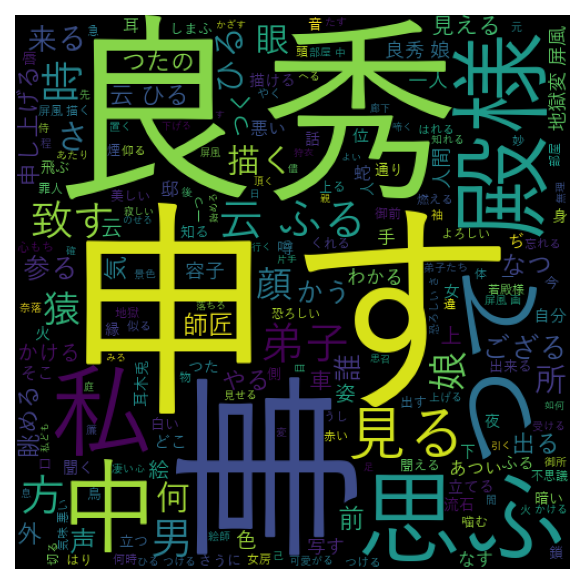

In [14]:
# ワードクラウドの生成表示
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wc = WordCloud(font_path="/c:/Windows/Fonts/YuGothM.ttc", width=500, height=500)
wc.generate(words)
plt.figure(dpi=150)     # dpi の数字を大きくすると，大きく表示
plt.imshow(wc)
plt.axis("off")         # 軸目盛りの非表示
plt.show()